In [1]:
!git clone https://github.com/Liza228ko/DM2026-Assignment-1.git
%cd DM2026-Assignment-1

Cloning into 'DM2026-Assignment-1'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 166 (delta 55), reused 47 (delta 47), pack-reused 96 (from 2)
Receiving objects: 100% (166/166), 12.40 MiB | 18.50 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/DM2026-Assignment-1


# Real World Classification

## Load data

Import the necessary libraries

In [2]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [4]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import pandas as pd

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    columns_with_nan_info = []

    # transform string to number and check for NaNs
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if df[col].isnull().any():
            columns_with_nan_info.append(col)

    if columns_with_nan_info:
        print("--- Median and Standard Deviation for Columns with Missing Values (before imputation) ---")
        for col in columns_with_nan_info:
            col_median = df[col].median()
            col_std = df[col].std()
            print(f"{col:<20} | Median: {col_median:.4f} | Std: {col_std:.4f}")
        print("-------------------------------------------------------------------------------------")
    else:
        print("No columns with missing values found before imputation.")

    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    if columns_with_nan_info:
        print("\n--- Columns with missing values new median and std (after imputation) ---")
        for col in columns_with_nan_info:
            col_median = df[col].median()
            col_std = df[col].std()
            print(f"{col:<20} | Median: {col_median:.4f} | Std: {col_std:.4f}")
        print("-------------------------------------------------------------------------")
    else:
        print("No columns with missing values found after imputation.")

    return df, feature_cols

df, feature_cols = data_preprocessing(df)


--- Median and Standard Deviation for Columns with Missing Values (before imputation) ---
SepalLengthCm        | Median: 6.3000 | Std: 1.0371
SepalWidthCm         | Median: 2.9000 | Std: 0.3896
PetalLengthCm        | Median: 5.0856 | Std: 1.5828
PetalWidthCm         | Median: 1.6000 | Std: 0.7067
BranchLength         | Median: 16.3000 | Std: 1.0352
-------------------------------------------------------------------------------------

--- Columns with missing values new median and std (after imputation) ---
SepalLengthCm        | Median: 6.3000 | Std: 1.0093
SepalWidthCm         | Median: 2.9000 | Std: 0.3724
PetalLengthCm        | Median: 5.0357 | Std: 1.5150
PetalWidthCm         | Median: 1.7000 | Std: 0.6946
BranchLength         | Median: 16.3000 | Std: 1.0110
-------------------------------------------------------------------------


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

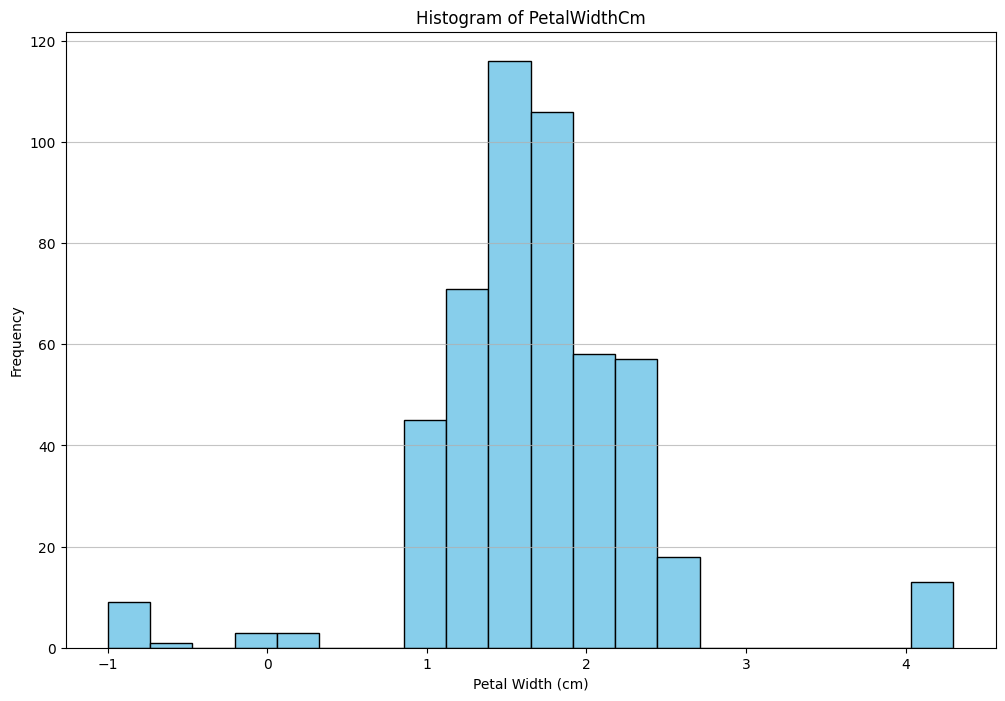

=== 4(b) Largest Positive Correlation ===
Feature: PetalWidthCompactness | Correlation: 0.9917

=== 4(c) Top 5 Strongest Negative Correlations ===
Feature: SepalWidthMajorAxis  | Correlation: -0.0964
Feature: SepalGlossIndex      | Correlation: -0.0952
Feature: SepalWidthCompactness | Correlation: -0.0885
Feature: SepalWidthCurvature  | Correlation: -0.0813
Feature: SepalWidthMinorAxis  | Correlation: -0.0744




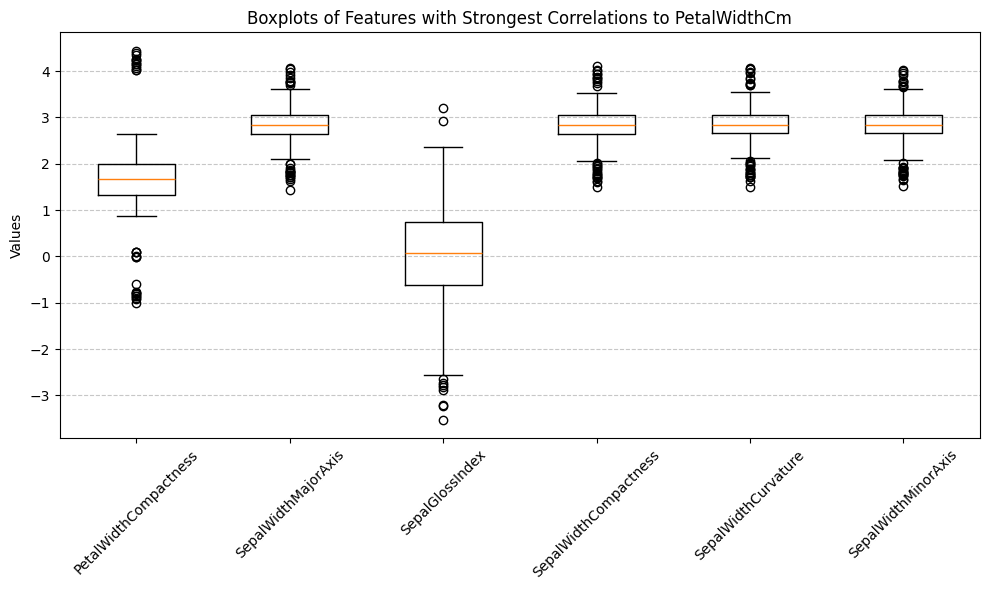

In [7]:
from sklearn.feature_selection import r_regression

# ----------------- Start your code below -----------------

# 4(a) Plot the histogram of "PetalWidthCm"
plt.figure(figsize=(12, 8))
plt.hist(df['PetalWidthCm'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

features_to_check = [col for col in df.columns if col not in ['Id', 'Species', 'PetalWidthCm']]
X = df[features_to_check]
y = df['PetalWidthCm']

correlations = r_regression(X, y)

corr_list = [(feat, corr) for feat, corr in zip(features_to_check, correlations)]

corr_list_sorted = sorted(corr_list, key=lambda x: x[1])

largest_positive_feat = corr_list_sorted[-1]
print("=== 4(b) Largest Positive Correlation ===")
print(f"Feature: {largest_positive_feat[0]} | Correlation: {largest_positive_feat[1]:.4f}\n")

top_5_negative = corr_list_sorted[:5]
print("=== 4(c) Top 5 Strongest Negative Correlations ===")
for feat, corr in top_5_negative:
    print(f"Feature: {feat:<20} | Correlation: {corr:.4f}")
print("\n")

features_to_plot = [largest_positive_feat[0]] + [feat for feat, corr in top_5_negative]

plt.figure(figsize=(10, 6))
plt.boxplot([df[f] for f in features_to_plot], tick_labels=features_to_plot)
plt.title('Boxplots of Features with Strongest Correlations to PetalWidthCm')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------

## Model Training

### Prepare the data

In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

=== Task 5(a): Loss Curves ===

Training: No Regularization
50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177568
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.512749676132389, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.573746996512145
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.57046113198

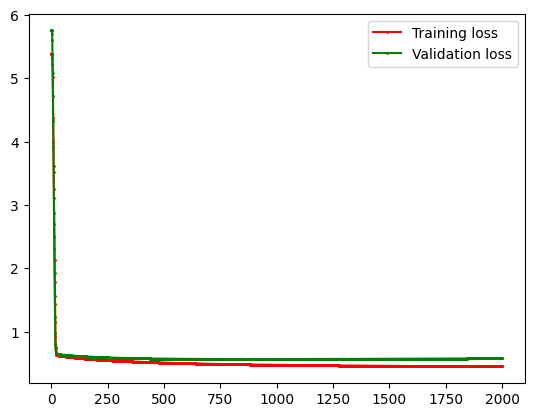


Training: L2 (lambda=0.01)
50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117252, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451082
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452545
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888323
750. Training loss: 0

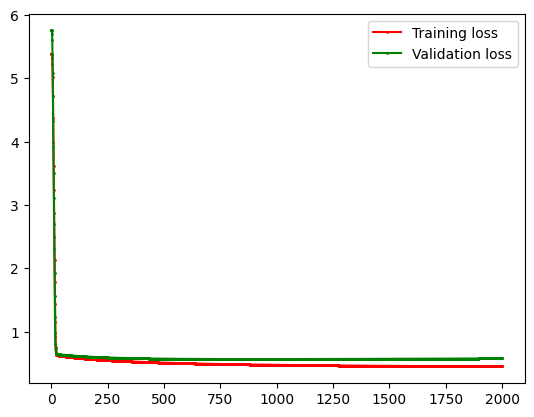


Training: L2 (lambda=1)
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.612622557656859
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908268
250. Training loss: 0.5571858255876307, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267104
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.5110797027848409, Val loss:0.5737215545999529
750. Training loss: 0.508656912

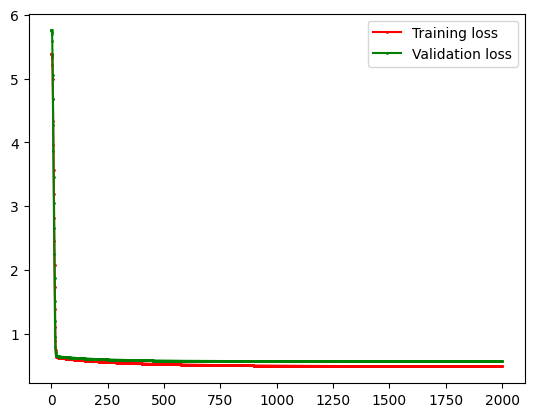


Training: L2 (lambda=100)
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.674

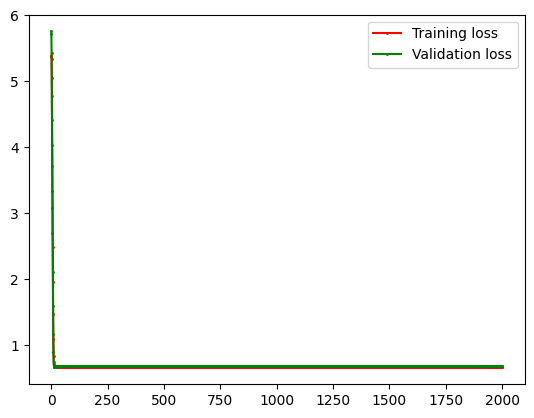


=== Task 5(b): Testing Results ===

Evaluation results for: No Regularization
=== Model Evaluation ===
Accuracy  : 0.7533
Precision : 0.7468
Recall    : 0.7763
F1-score  : 0.7613


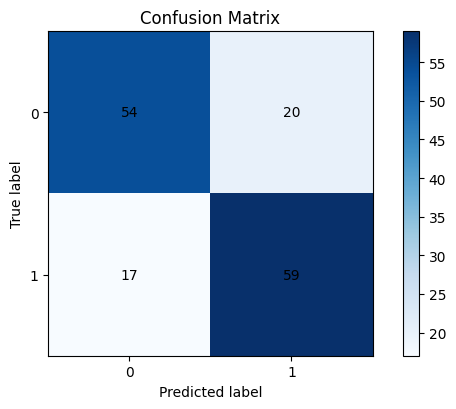


Evaluation results for: L2 (lambda=1)
=== Model Evaluation ===
Accuracy  : 0.7400
Precision : 0.7229
Recall    : 0.7895
F1-score  : 0.7547


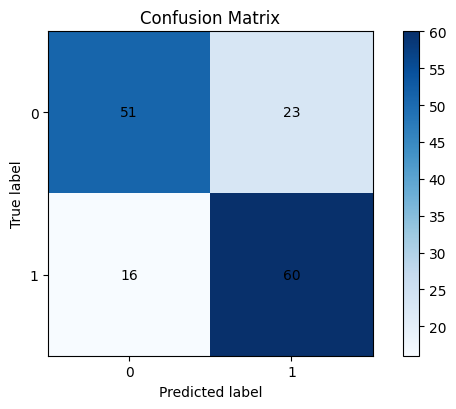

In [9]:
# Use the LinearModel to fit the data
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import numpy as np
import matplotlib.pyplot as plt

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Task 5(a): Plot loss curves for all settings
print("=== Task 5(a): Loss Curves ===")
settings_5a = [
    ("No Regularization", '', 0.0),
    ("L2 (lambda=0.01)", 'l2', 0.01),
    ("L2 (lambda=1)", 'l2', 1.0),
    ("L2 (lambda=100)", 'l2', 100.0)
]

models = {}

for title, reg_type, reg_lam in settings_5a:
    print(f"\nTraining: {title}")
    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=0.1, n_iteration=2000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lam)
    models[title] = model

# Task 5(b): Show testing results for No Regularization and L2 (lambda=1)
print("\n" + "="*40)
print("=== Task 5(b): Testing Results ===")
print("="*40)
settings_5b = ["No Regularization", "L2 (lambda=1)"]

for title in settings_5b:
    print(f"\nEvaluation results for: {title}")
    model = models[title]
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)
